### Set up and load data

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#load the volve dataset
raw_data = pd.read_excel('Volve production data.xlsx')

In [10]:
raw_data.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [11]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[ns]
 1   WELL_BORE_CODE            15634 non-null  object        
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  object        
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  object        
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  object        
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNULUS_PRESS 

In [12]:
df = raw_data[(raw_data['WELL_BORE_CODE'] == 'NO 15/9-F-14 H') & (raw_data['FLOW_KIND'] == 'production')]

In [14]:
df.shape

(3056, 24)

In [16]:
df['WELL_BORE_CODE'].unique()

array(['NO 15/9-F-14 H'], dtype=object)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3056 entries, 4967 to 8022
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   3056 non-null   datetime64[ns]
 1   WELL_BORE_CODE            3056 non-null   object        
 2   NPD_WELL_BORE_CODE        3056 non-null   int64         
 3   NPD_WELL_BORE_NAME        3056 non-null   object        
 4   NPD_FIELD_CODE            3056 non-null   int64         
 5   NPD_FIELD_NAME            3056 non-null   object        
 6   NPD_FACILITY_CODE         3056 non-null   int64         
 7   NPD_FACILITY_NAME         3056 non-null   object        
 8   ON_STREAM_HRS             3056 non-null   float64       
 9   AVG_DOWNHOLE_PRESSURE     3050 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  3050 non-null   float64       
 11  AVG_DP_TUBING             3050 non-null   float64       
 12  AVG_ANNULUS_PRESS     

### Plotting the raw_data curve

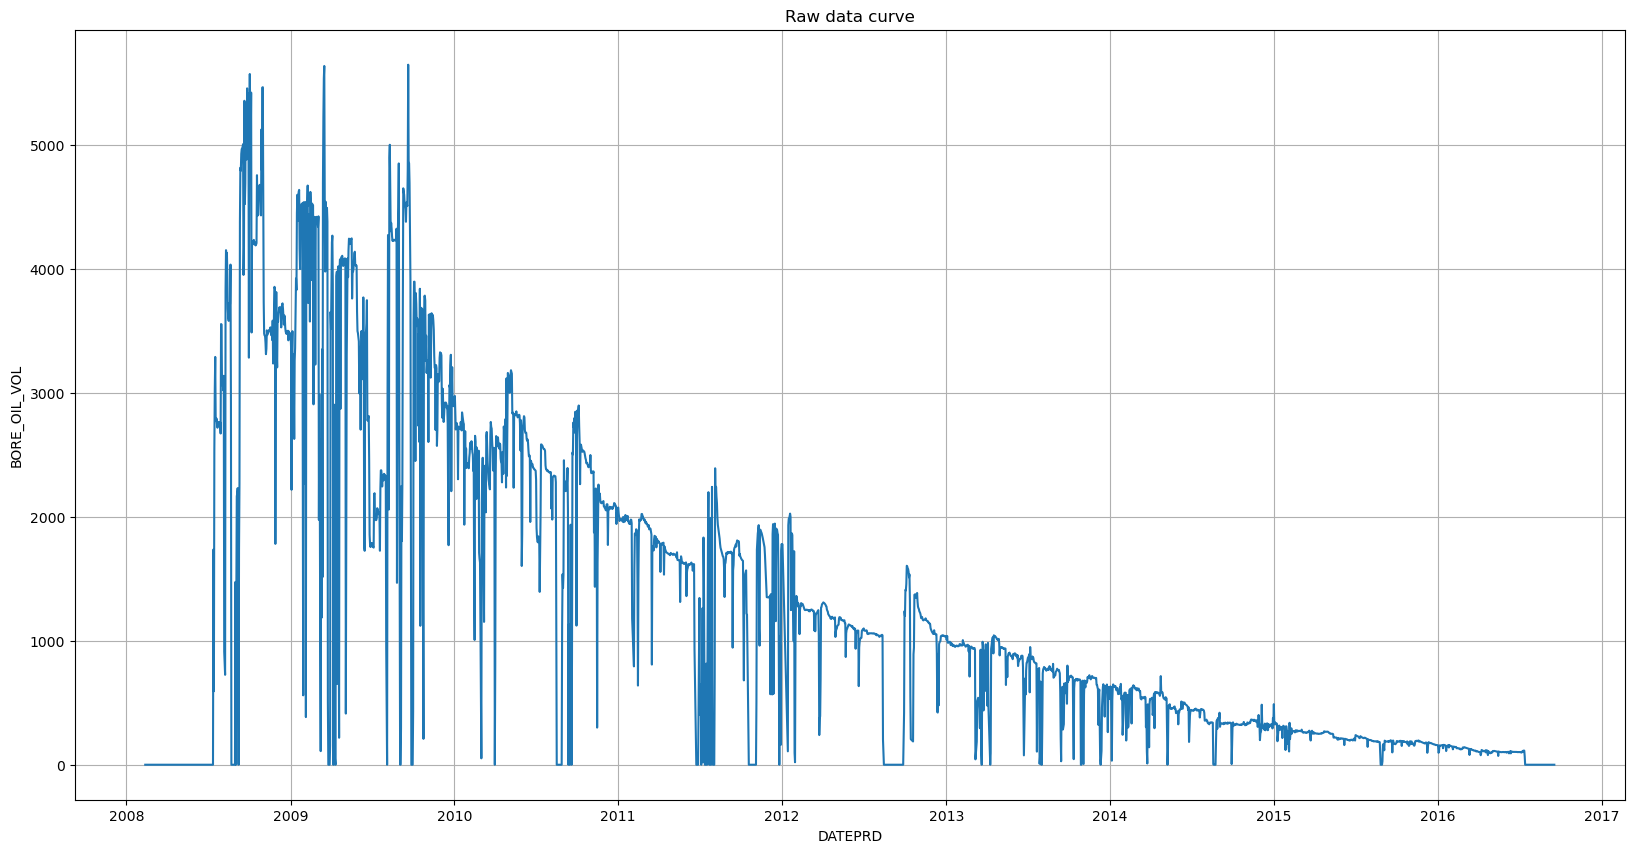

In [28]:
plt.figure(figsize=(20, 10))
plt.plot(df['DATEPRD'], df['BORE_OIL_VOL'])
plt.title('Raw data curve')
plt.xlabel('DATEPRD')
plt.ylabel('BORE_OIL_VOL')
plt.grid()
plt.show()

### Cleaning shut-in days + aggregating to monthly averages

In [31]:
# Remove shut-in days (days where the well produced zero oil)

df_clean = df[df['BORE_OIL_VOL'] > 0].copy()

print("Rows before removing shut-ins:", df.shape[0])
print("Rows after removing shut-ins:", df_clean.shape[0])

Rows before removing shut-ins: 3056
Rows after removing shut-ins: 2723


In [32]:
# Create a year-month period column to group by
df_clean['year_month'] = df_clean['DATEPRD'].dt.to_period('M')

# Aggregate to monthly averages
monthly = df_clean.groupby('year_month')['BORE_OIL_VOL'].mean().reset_index()

# Convert year_month back to an actual datetime for plotting
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

# Sort chronologically just to be safe
monthly = monthly.sort_values('year_month_dt').reset_index(drop=True)

print(monthly.shape)
monthly.head(10)

(97, 3)


,year_month,BORE_OIL_VOL,year_month_dt
0,2008-07,2699.214737,2008-07-01
1,2008-08,3220.057143,2008-08-01
2,2008-09,4092.723571,2008-09-01
3,2008-10,4607.001935,2008-10-01
4,2008-11,3480.320333,2008-11-01
5,2008-12,3554.815484,2008-12-01
6,2009-01,3728.150323,2009-01-01
7,2009-02,4067.177857,2009-02-01
8,2009-03,3357.201481,2009-03-01
9,2009-04,3220.150370,2009-04-01


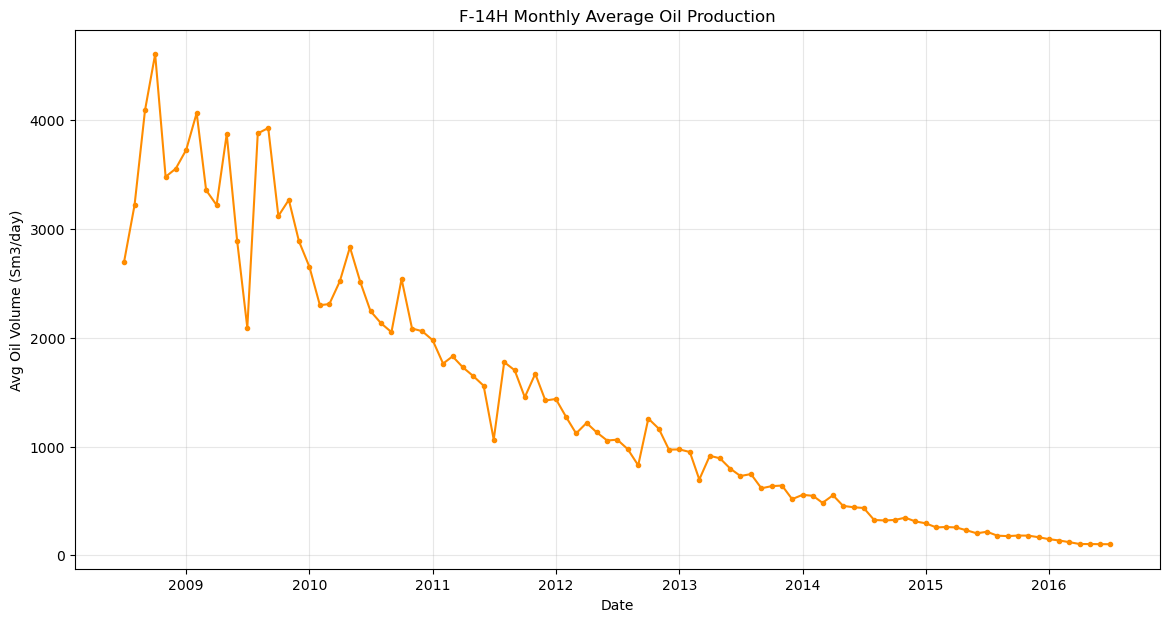

In [33]:
# Plot the monthly averaged curve
plt.figure(figsize=(14, 7))
plt.plot(monthly['year_month_dt'], monthly['BORE_OIL_VOL'], marker='o', markersize=3, color='darkorange')
plt.title('F-14H Monthly Average Oil Production')
plt.xlabel('Date')
plt.ylabel('Avg Oil Volume (Sm3/day)')
plt.grid(alpha=0.3)
plt.show()

### Prepare data for curve fitting

In [34]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

In [35]:
# Find the peak month (highest oil rate) - this becomes t=0

peak_idx = monthly['BORE_OIL_VOL'].idxmax()
print("Peak month:", monthly.loc[peak_idx, 'year_month_dt'], "| Rate:", monthly.loc[peak_idx, 'BORE_OIL_VOL'])

# Slice the data from the peak onward - this is our decline segment
decline = monthly.loc[peak_idx:].reset_index(drop=True)

# Create a simple time counter: 0, 1, 2, 3... months since peak
decline['t'] = np.arange(len(decline))

decline.head()

Peak month: 2008-10-01 00:00:00 | Rate: 4607.0019354838705


,year_month,BORE_OIL_VOL,year_month_dt,t
0,2008-10,4607.001935,2008-10-01,0
1,2008-11,3480.320333,2008-11-01,1
2,2008-12,3554.815484,2008-12-01,2
3,2009-01,3728.150323,2009-01-01,3
4,2009-02,4067.177857,2009-02-01,4


### Define the Arps exponential decline function

In [36]:
q = decline['BORE_OIL_VOL'].values   # actual oil rates
t = decline['t'].values               # months since peak
qi = q[0]                             # initial rate = the peak value itself

def exponential(t, D):
    return qi * np.exp(-D * t)

### Fit the exponential model

In [37]:
# p0 = starting guess for D (a small positive number is reasonable for a decline rate)
popt_exp, _ = curve_fit(exponential, t, q, p0=[0.05])

D_exp = popt_exp[0]
print("Best-fit D (exponential):", D_exp)

Best-fit D (exponential): 0.033219295221320076


In [44]:
#Generate predictions & evaluate the fit
pred_exp = exponential(t, D_exp)
r2_exp = r2_score(q, pred_exp)
rmse_exp = np.sqrt(mean_squared_error(q, pred_exp))

print("Exponential Model:")
print("R2:", r2_exp)
print("RMSE:", rmse_exp)


Exponential Model:
R2: 0.9427148747495947
RMSE: 279.35121791944295


### Plot exponential fit vs actual

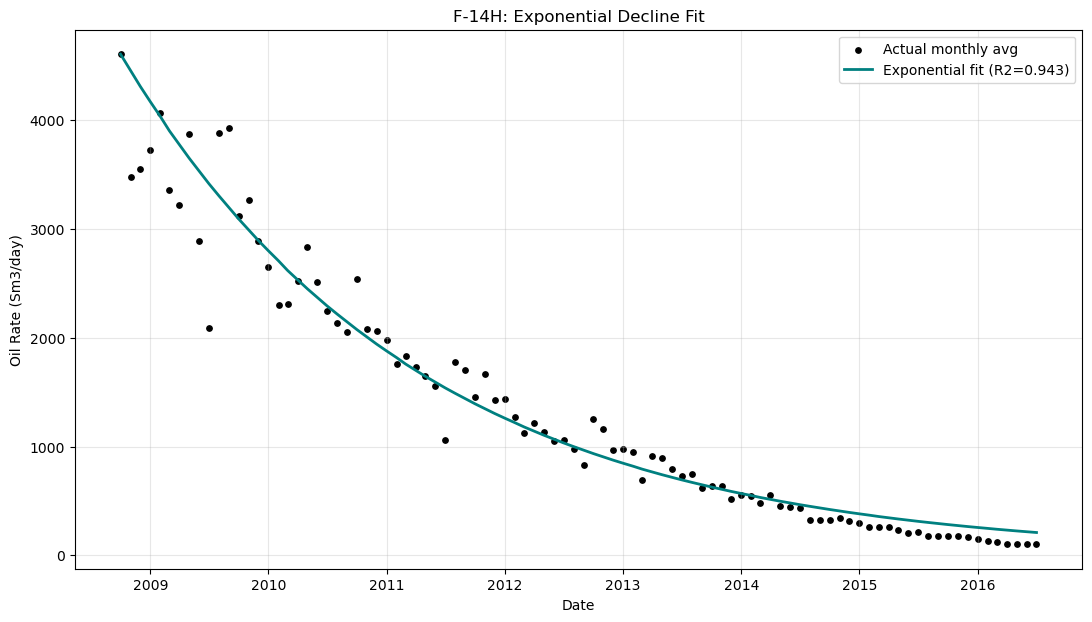

In [45]:
plt.figure(figsize=(13, 7))
plt.scatter(decline['year_month_dt'], q, color='black', s=15, label='Actual monthly avg')
plt.plot(decline['year_month_dt'], pred_exp, color='teal', linewidth=2, label=f'Exponential fit (R2={r2_exp:.3f})')
plt.title('F-14H: Exponential Decline Fit')
plt.xlabel('Date')
plt.ylabel('Oil Rate (Sm3/day)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Define and fit Harmonic and Hyperbolic models

In [46]:
def harmonic(t, D):
    return qi / (1 + D * t)

def hyperbolic(t, D, b):
    return qi / (1 + b * D * t)**(1/b)

# Fit harmonic
popt_harm, _ = curve_fit(harmonic, t, q, p0=[0.05])
D_harm = popt_harm[0]
pred_harm = harmonic(t, D_harm)

# Fit hyperbolic - notice it needs bounds this time, since b must stay between 0 and 2 to make physical sense
popt_hyp, _ = curve_fit(hyperbolic, t, q, p0=[0.05, 0.5], bounds=([0.0001, 0.0001], [2, 2]))
D_hyp, b_hyp = popt_hyp
pred_hyp = hyperbolic(t, D_hyp, b_hyp)

print("Harmonic D:", D_harm)
print("Hyperbolic D, b:", D_hyp, b_hyp)

Harmonic D: 0.06668954256423938
Hyperbolic D, b: 0.0332216401221894 0.00010000000000012027


### Compare all three models

In [47]:
r2_harm = r2_score(q, pred_harm)
rmse_harm = np.sqrt(mean_squared_error(q, pred_harm))

r2_hyp = r2_score(q, pred_hyp)
rmse_hyp = np.sqrt(mean_squared_error(q, pred_hyp))

print(f"{'Model':<12} {'R2':<10} {'RMSE':<10}")
print(f"{'Exponential':<12} {r2_exp:<10.4f} {rmse_exp:<10.1f}")
print(f"{'Harmonic':<12} {r2_harm:<10.4f} {rmse_harm:<10.1f}")
print(f"{'Hyperbolic':<12} {r2_hyp:<10.4f} {rmse_hyp:<10.1f}")

Model        R2         RMSE      
Exponential  0.9427     279.4     
Harmonic     0.8629     432.2     
Hyperbolic   0.9427     279.4     


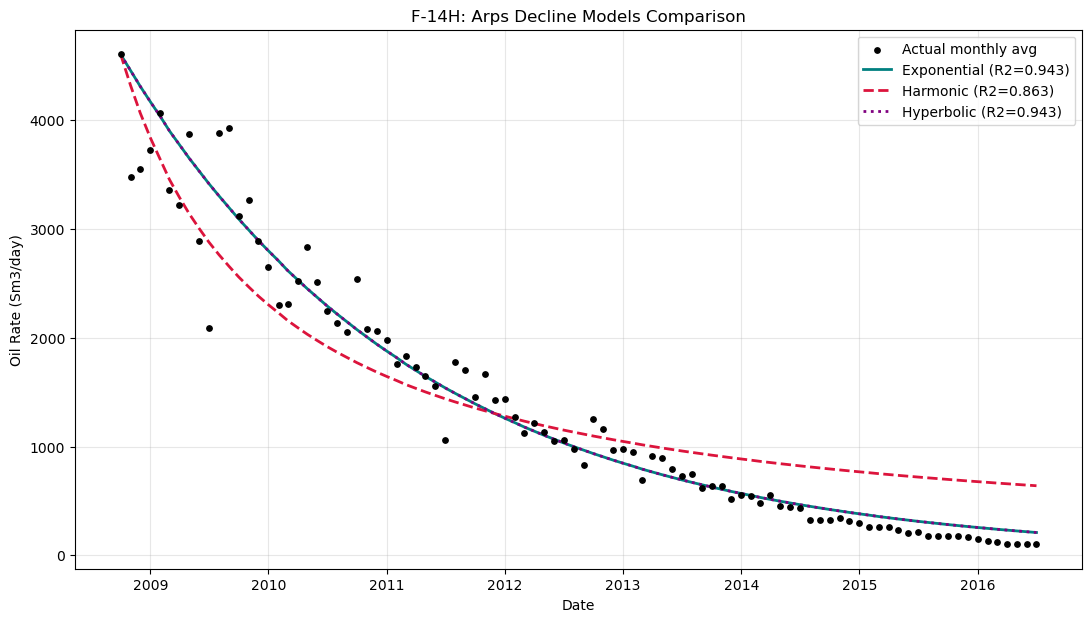

In [48]:
# Visual comparison of all three fits against actual data

plt.figure(figsize=(13, 7))
plt.scatter(decline['year_month_dt'], q, color='black', s=15, label='Actual monthly avg', zorder=5)
plt.plot(decline['year_month_dt'], pred_exp, color='teal', linewidth=2, label=f'Exponential (R2={r2_exp:.3f})')
plt.plot(decline['year_month_dt'], pred_harm, color='crimson', linewidth=2, linestyle='--', label=f'Harmonic (R2={r2_harm:.3f})')
plt.plot(decline['year_month_dt'], pred_hyp, color='purple', linewidth=2, linestyle=':', label=f'Hyperbolic (R2={r2_hyp:.3f})')
plt.title('F-14H: Arps Decline Models Comparison')
plt.xlabel('Date')
plt.ylabel('Oil Rate (Sm3/day)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### **Selected model: Exponential Decline**

The hyperbolic fit converged on a decline exponent of b ≈ 0.0001, effectively 
zero, which mathematically reduces the hyperbolic equation back to the 
exponential case. This is visually confirmed in the comparison plot, where the 
exponential and hyperbolic curves overlap almost perfectly. Harmonic decline, 
by contrast, clearly underperformed (R² = 0.8629) and visibly overshoots actual 
production in later years, indicating the well is declining faster than a 
harmonic model would predict.

### Chronological Train/Test Split

In [50]:
n = len(t)
split = int(n * 0.8)   # 80% train, 20% test

t_train, t_test = t[:split], t[split:]
q_train, q_test = q[:split], q[split:]

print("Total months:", n)
print("Train months:", split, "| Test months:", n - split)
print("Train period:", decline['year_month_dt'].iloc[0].date(), "to", decline['year_month_dt'].iloc[split-1].date())
print("Test period:", decline['year_month_dt'].iloc[split].date(), "to", decline['year_month_dt'].iloc[-1].date())

Total months: 94
Train months: 75 | Test months: 19
Train period: 2008-10-01 to 2014-12-01
Test period: 2015-01-01 to 2016-07-01


In [51]:
#Refit Arps on training data only, then forecast test period

popt_train, _ = curve_fit(exponential, t_train, q_train, p0=[0.05], maxfev=10000)
D_train = popt_train[0]

# Forecast the held-out test months using this training-only fit
arps_forecast = exponential(t_test, D_train)

r2_arps = r2_score(q_test, arps_forecast)
rmse_arps = np.sqrt(mean_squared_error(q_test, arps_forecast))

print("D (trained on train set only):", D_train)
print("Arps forecast - R2:", r2_arps, "| RMSE:", rmse_arps)

D (trained on train set only): 0.03283343605493123
Arps forecast - R2: -2.975643432176466 | RMSE: 117.40694856718935


### ML Model 1 - Random Forest using time only

In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_time = RandomForestRegressor(n_estimators=200, random_state=42)
rf_time.fit(t_train.reshape(-1, 1), q_train)

rf_time_forecast = rf_time.predict(t_test.reshape(-1, 1))

r2_rf_time = r2_score(q_test, rf_time_forecast)
rmse_rf_time = np.sqrt(mean_squared_error(q_test, rf_time_forecast))

print("Random Forest (time only) - R2:", r2_rf_time, "| RMSE:", rmse_rf_time)

Random Forest (time only) - R2: -6.045791914373272 | RMSE: 156.29856618514586


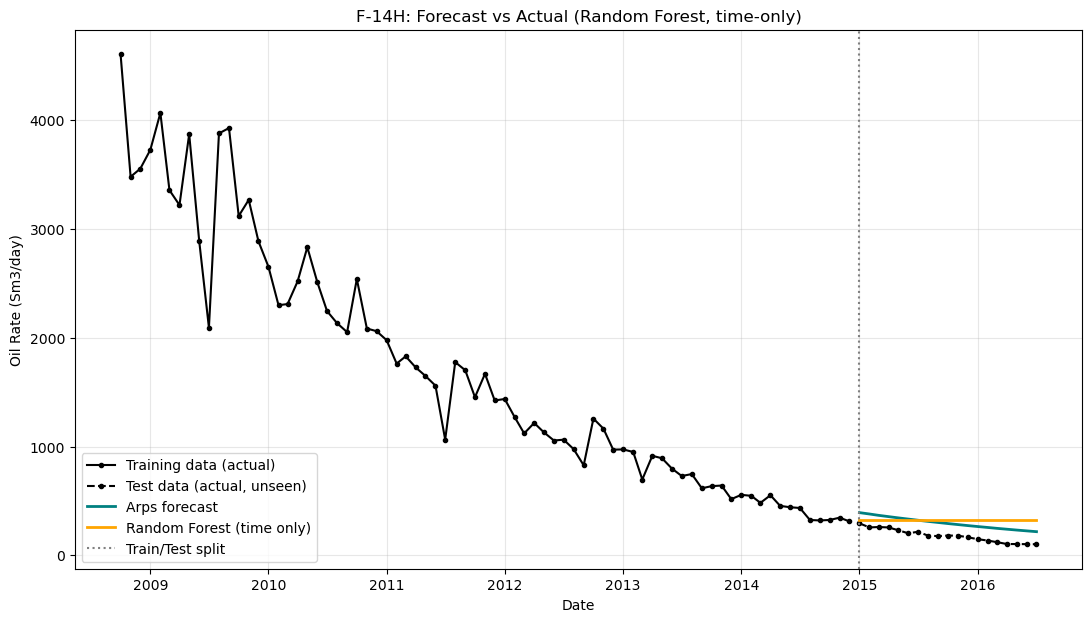

In [53]:
# Visualize it

plt.figure(figsize=(13, 7))
plt.plot(decline['year_month_dt'][:split], q_train, color='black', marker='o', markersize=3, label='Training data (actual)')
plt.plot(decline['year_month_dt'][split:], q_test, color='black', marker='o', markersize=3, linestyle='--', label='Test data (actual, unseen)')
plt.plot(decline['year_month_dt'][split:], arps_forecast, color='teal', linewidth=2, label='Arps forecast')
plt.plot(decline['year_month_dt'][split:], rf_time_forecast, color='orange', linewidth=2, label='Random Forest (time only)')
plt.axvline(decline['year_month_dt'].iloc[split], color='gray', linestyle=':', label='Train/Test split')
plt.title('F-14H: Forecast vs Actual (Random Forest, time-only)')
plt.xlabel('Date')
plt.ylabel('Oil Rate (Sm3/day)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ML Model 2 - Random Forest with lag features

In [54]:
def make_lag_df(series, n_lags=3):
    df_lag = pd.DataFrame({'q': series})
    for lag in range(1, n_lags + 1):
        df_lag[f'lag{lag}'] = df_lag['q'].shift(lag)
    return df_lag.dropna().reset_index(drop=True)

n_lags = 3
lag_df_train = make_lag_df(q_train, n_lags)

X_train_lag = lag_df_train[[f'lag{i}' for i in range(1, n_lags+1)]].values
y_train_lag = lag_df_train['q'].values

rf_lag = RandomForestRegressor(n_estimators=300, random_state=42)
rf_lag.fit(X_train_lag, y_train_lag)

print("Lag training data shape:", X_train_lag.shape)

Lag training data shape: (72, 3)


In [55]:
# Recursive forecast into the test period

history = list(q_train[-n_lags:])  # last 3 known REAL values from training
rf_lag_forecast = []

for step in range(len(q_test)):
    x_input = np.array(history[-1:-n_lags-1:-1]).reshape(1, -1)
    next_pred = rf_lag.predict(x_input)[0]
    rf_lag_forecast.append(next_pred)
    history.append(next_pred)

rf_lag_forecast = np.array(rf_lag_forecast)

r2_rf_lag = r2_score(q_test, rf_lag_forecast)
rmse_rf_lag = np.sqrt(mean_squared_error(q_test, rf_lag_forecast))

print("Random Forest (lag features) - R2:", r2_rf_lag, "| RMSE:", rmse_rf_lag)


Random Forest (lag features) - R2: -6.423068391999767 | RMSE: 160.42860921179732


### Model Comparison Summary

In [56]:
print(f"{'Model':<35} {'R2':<10} {'RMSE':<10}")
print(f"{'Arps Exponential':<35} {r2_arps:<10.4f} {rmse_arps:<10.1f}")
print(f"{'Random Forest (time only)':<35} {r2_rf_time:<10.4f} {rmse_rf_time:<10.1f}")
print(f"{'Random Forest (lag features)':<35} {r2_rf_lag:<10.4f} {rmse_rf_lag:<10.1f}")

Model                               R2         RMSE      
Arps Exponential                    -2.9756    117.4     
Random Forest (time only)           -6.0458    156.3     
Random Forest (lag features)        -6.4231    160.4     


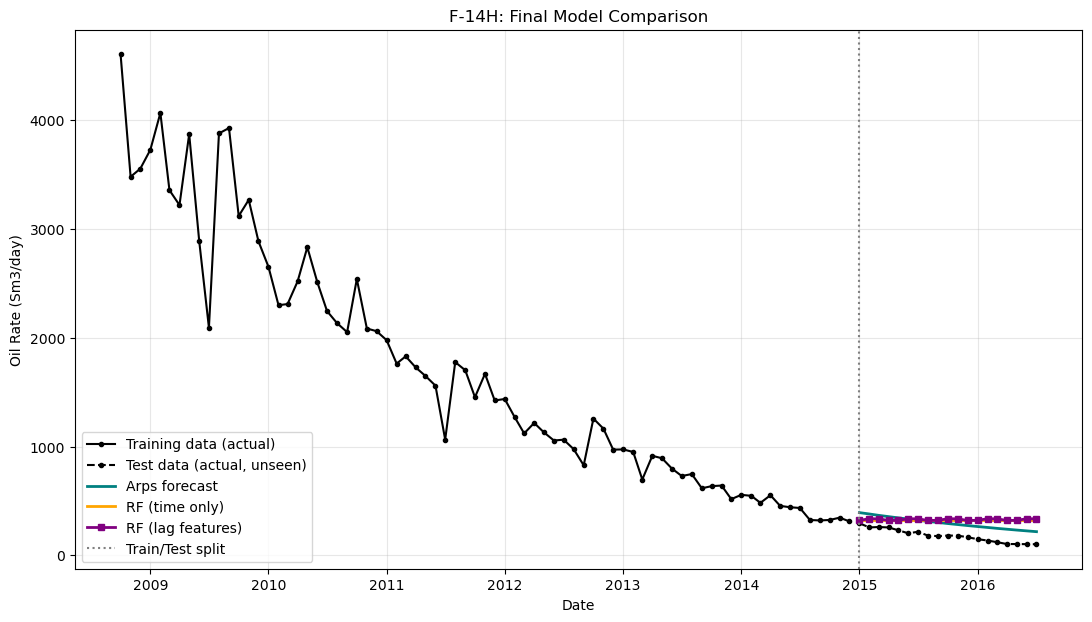

In [57]:
 #Final comparison plot - all models together

plt.figure(figsize=(13, 7))
plt.plot(decline['year_month_dt'][:split], q_train, color='black', marker='o', markersize=3, label='Training data (actual)')
plt.plot(decline['year_month_dt'][split:], q_test, color='black', marker='o', markersize=3, linestyle='--', label='Test data (actual, unseen)')
plt.plot(decline['year_month_dt'][split:], arps_forecast, color='teal', linewidth=2, label='Arps forecast')
plt.plot(decline['year_month_dt'][split:], rf_time_forecast, color='orange', linewidth=2, label='RF (time only)')
plt.plot(decline['year_month_dt'][split:], rf_lag_forecast, color='purple', linewidth=2, marker='s', markersize=4, label='RF (lag features)')
plt.axvline(decline['year_month_dt'].iloc[split], color='gray', linestyle=':', label='Train/Test split')
plt.title('F-14H: Final Model Comparison')
plt.xlabel('Date')
plt.ylabel('Oil Rate (Sm3/day)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

######## Final Conclusion - Traditional vs ML Decline Forecasting (F-14H)

Result: Arps Exponential decline outperformed both ML approaches on the 
held-out 2015-2016 test period.

| Model                       | R²      | RMSE  |
|-----------------------------|---------|-------|
| Arps Exponential             | -2.976  | 117.4 |
| Random Forest (time only)    | -6.046  | 156.3 |
| Random Forest (lag features) | -6.423  | 160.4 |

why Arps won: Random Forest is a tree-based model - it predicts by sorting 
inputs into "buckets" learned during training and returning that bucket's 
average value. Once test-period values (time, or lagged production) fell 
outside the range seen in training, the model had no bucket to place them in 
and simply repeated its last learned value - producing a near-flat forecast 
regardless of whether raw time or lag features were used. Arps, by contrast, is 
a continuous mathematical equation with no such ceiling, so it kept declining 
smoothly as t increased.

Note on model choice: Random Forest was tested here as a representative 
"off-the-shelf" ML approach. Its poor performance isn't specific to Random 
Forest alone - it reflects a structural limitation shared by all tree-based 
models (Gradient Boosting, XGBoost, etc.) when applied to extrapolation tasks. 
A more rigorous model selection process would rule out tree-based models at 
the reasoning stage for this type of problem, favoring equation-based or 
sequence-aware models (e.g. ARIMA, LSTM) instead.

Honest limitation: Even Arps overshot the actual decline in 2015-2016 - 
the well's true production fell faster than its 2008-2014 trend predicted, 
likely due to accelerating water breakthrough as the field's water injection support pushed 
water into the producing well over time as observed from the raw_data

Future work: Extend this with multivariate ML (pressure, water cut, choke 
size as features - water cut showed strong feature importance in earlier 
testing), test LSTM/sequence models built for extrapolation, and validate 
across multiple wells (e.g. F-12H) rather than a single well.